# Otoczka wypukła - dolna i górna otoczka

In [186]:
%run interface.ipynb

### Algorytm bez wizualizacji

In [187]:
def position(a, b, c):
    # okresla polozenie punktu wzgledem zadanej prostej
    result = (b.x - a.x) * (c.y - a.y) - (b.y - a.y) * (c.x - a.x)
    return 1 if result > 0 else -1 if result < 0 else 0

In [188]:
def upper_and_lower_hull(points):
    
    if len(points) <= 2:
        return points
    
    # początkowe sortowanie wszystkich punktów
    sorted_points = sorted(points, key = lambda point: (point.x, point.y))
    
    # przyporządkowanie początkowych punktów do obu elementów otoczki
    upper_hull = [sorted_points[0], sorted_points[1]]
    lower_hull = [sorted_points[0], sorted_points[1]]
    
    for point in sorted_points:
        
        while len(upper_hull) >= 2 and position(upper_hull[-2], upper_hull[-1], point) != -1:
            upper_hull.pop()
        upper_hull.append(point)
        
        while len(lower_hull) >= 2 and position(lower_hull[-2], lower_hull[-1], point) != 1:
            lower_hull.pop()
        lower_hull.append(point)
    
    upper_hull.pop()
    lower_hull.reverse()
    lower_hull.pop()
    
    return upper_hull + lower_hull

### Stwórz swój własny zestaw punktów

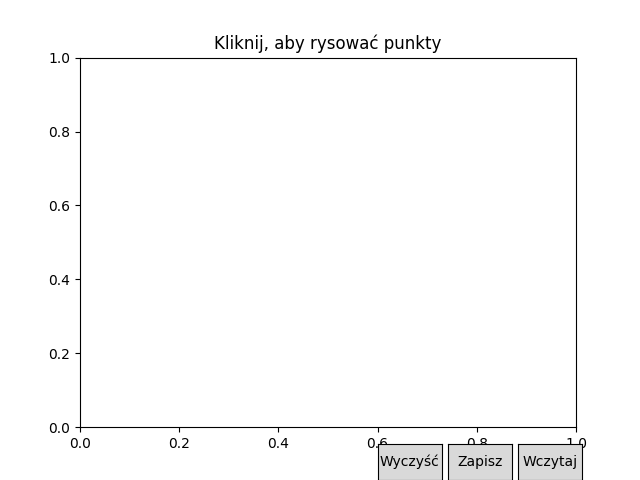

In [189]:
PolygonDrawer()

### Algorytm wraz z wizualizacjami

In [190]:
def upper_and_lower_hull_visualisation(points):
    
    if len(points) <= 2:
        return points
    
    sorted_points = sorted(points, key = lambda point: (point.x, point.y))
    
    upper_hull = [sorted_points[0], sorted_points[1]]
    lower_hull = [sorted_points[0], sorted_points[1]]
    
    for point in sorted_points:
        save_frame(points, upper_hull, point, 'frames')
        
        while len(upper_hull) >= 2 and position(upper_hull[-2], upper_hull[-1], point) != -1:
            upper_hull.pop()
            save_frame(points, upper_hull, point, 'frames')
        upper_hull.append(point)
    
    upper_hull.reverse()
    
    for point in sorted_points:
        save_frame(points, upper_hull + lower_hull, point, 'frames')
        
        while len(lower_hull) >= 2 and position(lower_hull[-2], lower_hull[-1], point) != 1:
            lower_hull.pop()
            save_frame(points, upper_hull + lower_hull, point, 'frames')
        lower_hull.append(point)
    
    upper_hull.reverse()
    upper_hull.pop()
    lower_hull.reverse()
    lower_hull.pop()
    
    return upper_hull + lower_hull

In [191]:
with open('points.json') as f:
    points = json.load(f)
points = [Point(x, y) for x, y in points]
upper_and_lower_hull_visualisation(points)
animate_from_folder('frames')